# 00. ResNet50 baseline 학습

이 노트북은 공통 시작점이 되는 `baseline_resnet50_float.h5`를 생성합니다.

이후 4개 실험 노트북은 모두 이 baseline을 새로 load해서 시작합니다.
이렇게 해야 실험 비교가 공정하고, TensorFlow graph 누적으로 인한 OOM을 줄일 수 있습니다.


## 필요 패키지

Jetson Thor 환경에 이미 설치되어 있으면 아래 셀은 실행하지 않아도 됩니다.

TensorFlow Model Optimization Toolkit이 없을 때만 `%pip install tensorflow-model-optimization`을 실행하세요.


In [ ]:
# 필요할 때만 주석을 풀고 실행하세요.
# %pip install -q tensorflow-model-optimization


In [1]:
import os
import gc
import glob
import zipfile
from pathlib import Path

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.keras.compat import keras

print("TensorFlow:", tf.__version__)
print("TFMOT:", tfmot.__version__)
print("NumPy:", np.__version__)

# GPU 메모리를 처음부터 전부 잡지 않도록 설정합니다.
# Jetson에서 OOM을 줄이는 데 도움이 됩니다.
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("memory_growth 설정 생략:", e)

# 공통 설정
IMG_SIZE = 64
NUM_CLASSES = 3
SEED = 123

# OOM이 나면 가장 먼저 BATCH_SIZE를 4 또는 2로 낮추세요.
BATCH_SIZE = 8

# Jetson Thor에서 데이터셋 위치가 다르면 여기를 수정하세요.
# 또는 터미널에서 export RPS_DATASET_DIR=/your/path/RPS_Dataset 으로 지정해도 됩니다.
DEFAULT_DATASET_DIR = "/home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/files/RPS_Dataset"
DATASET_DIR = Path(os.environ.get("RPS_DATASET_DIR", DEFAULT_DATASET_DIR))

# Colab에서 실행할 경우의 기본 경로도 자동 확인합니다.
if not DATASET_DIR.exists() and Path("/content/RPS_Dataset").exists():
    DATASET_DIR = Path("/content/RPS_Dataset")

# 결과 저장 폴더
SAVE_DIR = Path(os.environ.get("RPS_SAVE_DIR", str(Path.cwd() / "rps_outputs")))
SAVE_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_MODEL_PATH = SAVE_DIR / "baseline_resnet50_float.h5"
CACHE_NPZ_PATH = SAVE_DIR / f"rps_dataset_cache_{IMG_SIZE}.npz"

print("DATASET_DIR:", DATASET_DIR)
print("SAVE_DIR:", SAVE_DIR)
print("BASELINE_MODEL_PATH:", BASELINE_MODEL_PATH)


TensorFlow: 2.21.0
TFMOT: 0.8.1
NumPy: 2.4.6
GPUs: []
DATASET_DIR: /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/files/RPS_Dataset
SAVE_DIR: /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/notebooks_jh/rps_outputs
BASELINE_MODEL_PATH: /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/notebooks_jh/rps_outputs/baseline_resnet50_float.h5


In [2]:
def load_rps_dataset(dataset_dir, img_size=64, seed=123):
    # RPS_Dataset/
    #   0/ : scissors
    #   1/ : rock
    #   2/ : paper
    # 구조를 읽어 train/test numpy 배열로 변환합니다.
    dataset_dir = Path(dataset_dir)
    if not dataset_dir.exists():
        raise FileNotFoundError(f"DATASET_DIR가 존재하지 않습니다: {dataset_dir}")

    first = True

    for ind in range(NUM_CLASSES):
        pattern = str(dataset_dir / str(ind) / "*.*")
        files = sorted(glob.glob(pattern))
        print(f"class {ind}: {len(files)} files")

        if len(files) == 0:
            raise FileNotFoundError(f"이미지를 찾지 못했습니다: {pattern}")

        images = []
        for f in files:
            img = cv2.imread(f, cv2.IMREAD_COLOR)
            if img is None:
                print("이미지 읽기 실패:", f)
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)

        tmpx = np.array(images, dtype=np.uint8)
        tmpy = np.array([ind] * len(tmpx), dtype=np.int64)

        xtrain, xtest, ytrain, ytest = train_test_split(
            tmpx, tmpy, test_size=0.2, random_state=seed, stratify=tmpy
        )

        if first:
            train_data = xtrain
            train_labels = ytrain
            test_data = xtest
            test_labels = ytest
            first = False
        else:
            train_data = np.concatenate((train_data, xtrain), axis=0)
            train_labels = np.concatenate((train_labels, ytrain), axis=0)
            test_data = np.concatenate((test_data, xtest), axis=0)
            test_labels = np.concatenate((test_labels, ytest), axis=0)

    return train_data, train_labels, test_data, test_labels


def prepare_data():
    # 첫 실행 때는 이미지 폴더에서 데이터를 읽고,
    # 이후 실행부터는 npz 캐시를 사용해 시간을 줄입니다.
    if CACHE_NPZ_PATH.exists():
        print("캐시 데이터 로드:", CACHE_NPZ_PATH)
        data = np.load(CACHE_NPZ_PATH)
        train_data = data["train_data"]
        train_labels = data["train_labels"]
        test_data = data["test_data"]
        test_labels = data["test_labels"]
    else:
        print("이미지 폴더에서 데이터 로드:", DATASET_DIR)
        train_data, train_labels, test_data, test_labels = load_rps_dataset(
            DATASET_DIR, IMG_SIZE, SEED
        )
        np.savez_compressed(
            CACHE_NPZ_PATH,
            train_data=train_data,
            train_labels=train_labels,
            test_data=test_data,
            test_labels=test_labels
        )
        print("캐시 저장:", CACHE_NPZ_PATH)

    print("train_data:", train_data.shape, train_data.dtype)
    print("train_labels:", train_labels.shape)
    print("test_data:", test_data.shape, test_data.dtype)
    print("test_labels:", test_labels.shape)

    return train_data, train_labels, test_data, test_labels


train_data, train_labels, test_data, test_labels = prepare_data()

# 데이터 보강
# 기존 rotation_range=0.2는 0.2도가 되어 거의 회전하지 않습니다.
# 여기서는 20도로 수정했습니다.
img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.6, 1.4),
    zoom_range=0.2
)

train_gen = img_gen_train.flow(
    train_data,
    train_labels,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)


이미지 폴더에서 데이터 로드: /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/files/RPS_Dataset
class 0: 903 files
class 1: 907 files
class 2: 907 files
캐시 저장: /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/notebooks_jh/rps_outputs/rps_dataset_cache_64.npz
train_data: (2172, 64, 64, 3) uint8
train_labels: (2172,)
test_data: (545, 64, 64, 3) uint8
test_labels: (545,)


In [3]:
def build_resnet50_rps_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # ResNet50은 ImageNet 전처리 기준을 사용합니다.
    x = keras.applications.resnet.preprocess_input(inputs)

    base_model = keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_tensor=x
    )

    # OOM 방지를 위해 기본값은 backbone freeze입니다.
    # 정확도가 부족하면 UNFREEZE_LAST_N을 20~40 정도로 높여 마지막 일부 layer만 fine-tuning하세요.
    UNFREEZE_LAST_N = 0

    for layer in base_model.layers:
        layer.trainable = False

    if UNFREEZE_LAST_N > 0:
        for layer in base_model.layers[-UNFREEZE_LAST_N:]:
            if not isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = True

    x = base_model.output
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model


model = build_resnet50_rps_model()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 64, 64, 3)]          0         []                            
                                                                                                  
 tf.__operators__.getitem (  (None, 64, 64, 3)            0         ['input_1[0][0]']             
 SlicingOpLambda)                                                                                 
                                                                                                  
 tf.nn.bias_add (TFOpLambda  (None, 64, 64, 3)            0         ['tf.__operators__.getitem[0][
 )                                                                  0]']                          
                                                                                              

In [4]:
BASELINE_EPOCHS = 10

callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(BASELINE_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_gen,
    epochs=BASELINE_EPOCHS,
    validation_data=(test_data, test_labels),
    callbacks=callbacks
)


Epoch 1/10


I0000 00:00:1782048061.787253  565259 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


272/272 [==============================] - ETA: 0s - loss: 1.3563 - accuracy: 0.5511
Epoch 1: val_accuracy improved from -inf to 0.81101, saving model to /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/notebooks_jh/rps_outputs/baseline_resnet50_float.h5


/home/jaehun/.venv/lib/python3.12/site-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


272/272 [==============================] - 42s 148ms/step - loss: 1.3563 - accuracy: 0.5511 - val_loss: 0.5134 - val_accuracy: 0.8110
Epoch 2/10
272/272 [==============================] - ETA: 0s - loss: 0.7286 - accuracy: 0.7431
Epoch 2: val_accuracy improved from 0.81101 to 0.86239, saving model to /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/notebooks_jh/rps_outputs/baseline_resnet50_float.h5
272/272 [==============================] - 36s 134ms/step - loss: 0.7286 - accuracy: 0.7431 - val_loss: 0.4106 - val_accuracy: 0.8624
Epoch 3/10
272/272 [==============================] - ETA: 0s - loss: 0.5909 - accuracy: 0.7956
Epoch 3: val_accuracy improved from 0.86239 to 0.90459, saving model to /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/notebooks_jh/rps_outputs/baseline_resnet50_float.h5
272/272 [==============================] - 39s 145ms/step - loss: 0.5909 - accuracy: 0.7956 - val_loss: 0.3293 - val_accuracy: 0.9046
Epoch 4/10
272/272 [======

In [5]:
# 최종 평가
best_model = keras.models.load_model(BASELINE_MODEL_PATH, compile=False)
best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
loss, acc = best_model.evaluate(test_data, test_labels, verbose=0)
print(f"baseline loss: {loss:.4f}, accuracy: {acc:.4f}")
print("saved:", BASELINE_MODEL_PATH)


baseline loss: 0.2795, accuracy: 0.9339
saved: /home/jaehun/jh/SYS_lecture/SYS5284/OnDeviceAI-Lightweighting-Lab/notebooks_jh/rps_outputs/baseline_resnet50_float.h5


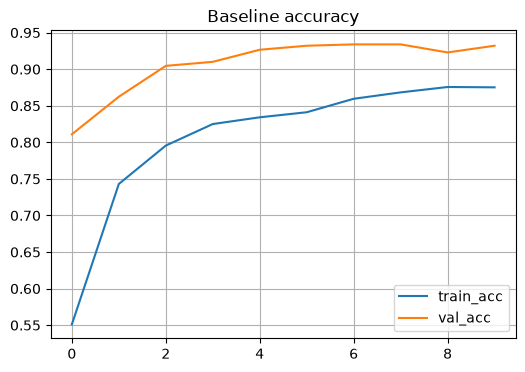

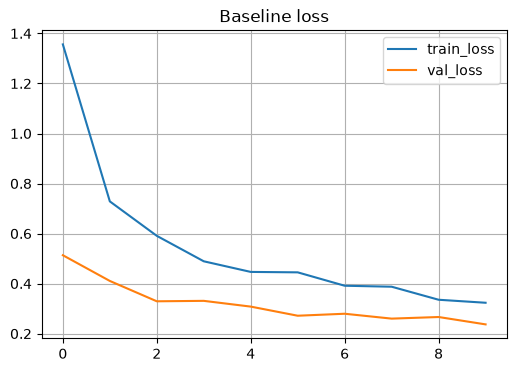

In [6]:
# 학습 곡선 확인
plt.figure(figsize=(6, 4))
plt.plot(history.history.get("accuracy", []), label="train_acc")
plt.plot(history.history.get("val_accuracy", []), label="val_acc")
plt.grid(True)
plt.legend()
plt.title("Baseline accuracy")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history.history.get("loss", []), label="train_loss")
plt.plot(history.history.get("val_loss", []), label="val_loss")
plt.grid(True)
plt.legend()
plt.title("Baseline loss")
plt.show()


In [7]:
del model, best_model
gc.collect()
tf.keras.backend.clear_session()
print("baseline notebook done.")


baseline notebook done.
